In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #...
import math
myplate=sns.color_palette("Paired")
sns.set(style='white', palette=myplate)

import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

clrs = ["#ADD8E6","#FF0000"]
mypalette = sns.set_palette(sns.color_palette(clrs))

print('^^Importing Important Stuff^^')

/kaggle/input/jobs-dataset-from-glassdoor/salary_data_cleaned.csv
/kaggle/input/jobs-dataset-from-glassdoor/glassdoor_jobs.csv
/kaggle/input/jobs-dataset-from-glassdoor/eda_data.csv
^^Importing Important Stuff^^


# EDA

In [2]:
sal_path = "/kaggle/input/jobs-dataset-from-glassdoor/eda_data.csv"
sal = pd.read_csv(sal_path, index_col = 0)
sal.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,age,python_yn,R_yn,spark,aws,excel,job_simp,seniority,desc_len,num_comp
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,47,1,0,0,0,1,data scientist,na,2536,0
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,36,1,0,0,0,0,data scientist,na,4783,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,10,1,0,1,0,1,data scientist,na,3461,0
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,55,1,0,0,0,0,data scientist,na,3883,3
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,22,1,0,0,0,1,data scientist,na,2728,3


In [3]:
sal.describe()

,Rating,Founded,hourly,employer_provided,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,3.618868,1837.154987,0.032345,0.022911,74.719677,128.149596,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,0.801210,497.183763,0.177034,0.149721,30.980593,45.220324,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


In [4]:
sal.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
hourly               0
employer_provided    0
min_salary           0
max_salary           0
avg_salary           0
company_txt          0
job_state            0
same_state           0
age                  0
python_yn            0
R_yn                 0
spark                0
aws                  0
excel                0
job_simp             0
seniority            0
desc_len             0
num_comp             0
dtype: int64

In [5]:
cate = []
nume = []
for column in sal.columns:
    if sal[column].dtypes == 'object':
        cate.append(column)
    else:
        nume.append(column)
        
cate= ['Job Title',
 'Company Name',
 'Location',
 'Headquarters',
 'Size',
 'Type of ownership',
 'Industry',
 'Sector',
 'Revenue',
 'Competitors',
 'job_state',
 'job_simp',
 'seniority']

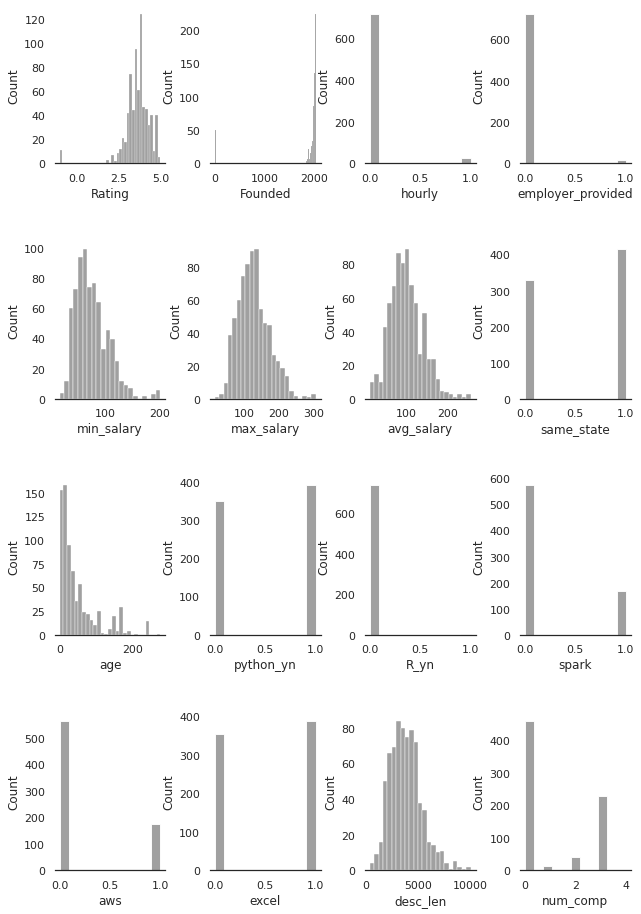

In [6]:
m=math.ceil(math.sqrt(len(nume)))
n=math.ceil(len(nume)/m)


fig, axes = plt.subplots(m,n,figsize=(10,15))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.5)
sns.despine(left=True)
for i in range(m):
    for j in range(n):
        sns.histplot(ax=axes[i,j], data=sal, x=nume[i*n+j], color = 'grey')
        if i*n+j==len(nume)-1:
            break

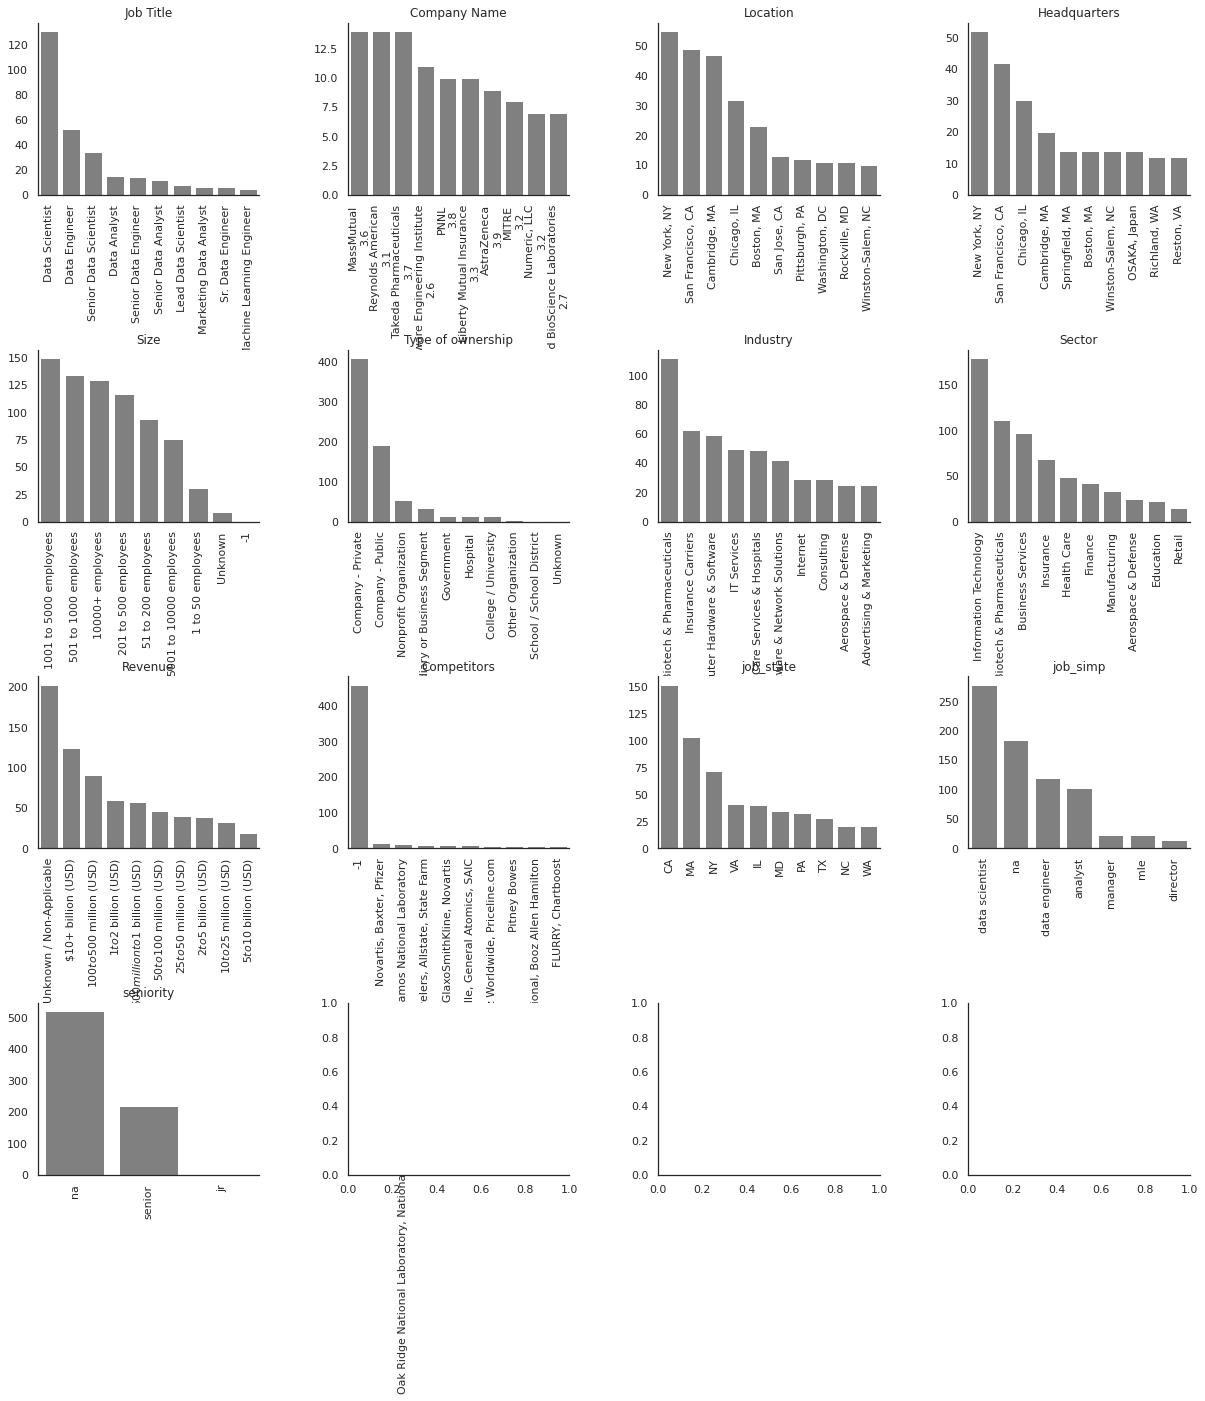

In [7]:
m=math.ceil(math.sqrt(len(cate)))
n=math.ceil(len(cate)/m)
fig, axes = plt.subplots(m,n,figsize=(20,20))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.9)

sns.despine()
for i in range(m):
    for j in range(n):
        sns.barplot(x= sal[cate[i*n+j]].value_counts()[:10].index,
                    y= sal[cate[i*n+j]].value_counts()[:10].values,
                   ax=axes[i,j], color = 'grey')
        axes[i,j].tick_params(axis='x', labelrotation=90)
        axes[i,j].title.set_text(cate[i*n+j])
        if i*n+j==len(cate)-1:
            break

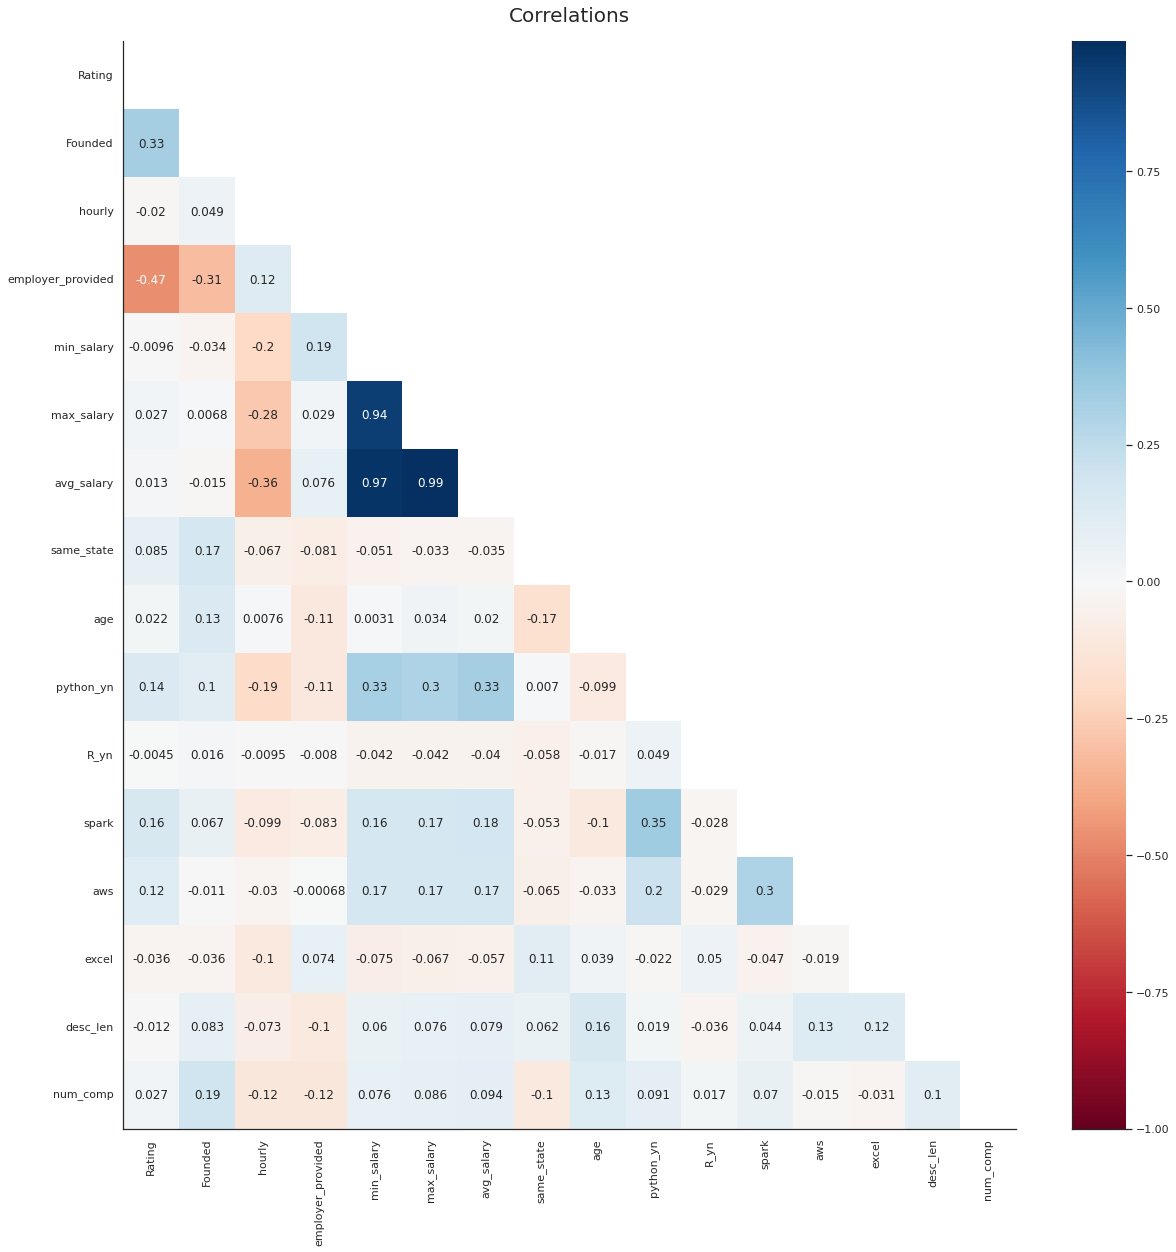

In [8]:
plt.figure(figsize= (20,20))
sns.heatmap(sal.corr(),vmin = -1, cmap = 'RdBu', annot = True, mask = np.triu(np.ones_like(sal.corr())))
plt.title('Correlations', fontsize = 20, pad = 20)
sns.despine()
plt.show()

<Figure size 1440x1440 with 0 Axes>

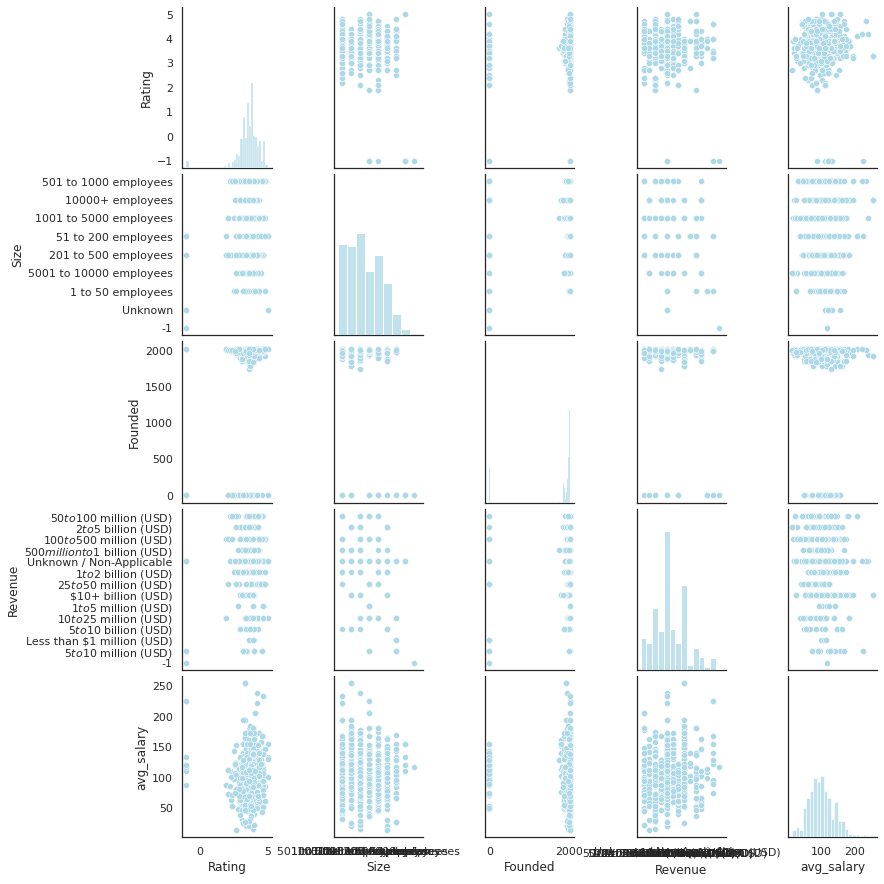

In [9]:
plt.figure(figsize= (20,20))
sns.pairplot(sal, x_vars = ['Rating', 'Size', 'Founded', 'Revenue', 'avg_salary'], y_vars = ['Rating', 'Size', 'Founded', 'Revenue', 'avg_salary'])
sns.despine()
plt.show()

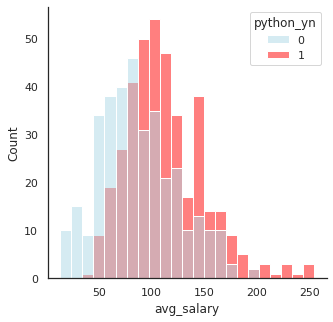

In [10]:
plt.figure(figsize= (5,5))
sns.histplot(data = sal, x = 'avg_salary', hue = 'python_yn')
sns.despine()
plt.show()